# Clasificación de galaxias: Spiral vs Elliptical

## Objetivo del proyecto

Este proyecto busca clasificar galaxias en dos categorías morfológicas: `spiral` y `elliptical`, a partir de imágenes astronómicas.  
Se parte desde exploración y preparación de datos, para luego construir y comparar distintos modelos de visión computacional.

## Flujo de trabajo

1. Carga y exploración de datos  
2. Limpieza y preparación  
3. Construcción de etiquetas  
4. División train / validation / test  
5. Pipeline de datos en PyTorch  
6. Modelo 1: SimpleCNN baseline  
7. Modelo 2: BetterCNN + Data Augmentation  
8. Modelo 3: Transfer Learning  
9. Comparación final y conclusiones

In [119]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [120]:
RANDOM_STATE = 42
IMG_SIZE = 128
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3060


# 1. Carga y exploración de datos

In [121]:
DATA_PATH = "../data"

mapping_path = os.path.join(DATA_PATH, "gz2_filename_mapping.csv")
labels_path = os.path.join(DATA_PATH, "gz2_hart16.csv")

mapping_df = pd.read_csv(mapping_path)
labels_df = pd.read_csv(labels_path)

print("Mapping shape:", mapping_df.shape)
print("Labels shape:", labels_df.shape)

Mapping shape: (355990, 3)
Labels shape: (239695, 231)


In [122]:
mapping_df.head()

,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


In [123]:
labels_df.head()

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [124]:
print(labels_df.columns.tolist())
print("objid in mapping:", "objid" in mapping_df.columns)
print("objid in labels:", "objid" in labels_df.columns)

['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction', 't01_smooth_or_features_a03_star_or_artifact_d

## Observaciones iniciales

En esta etapa se revisa la estructura de los datos disponibles, la correspondencia entre identificadores y etiquetas, y las columnas necesarias para construir el problema de clasificación binaria.

# 2. Preparación de datos y construcción de etiquetas

In [125]:
merged_df = pd.merge(
    mapping_df,
    labels_df,
    left_on="objid",
    right_on="dr7objid",
    how="inner"
)

print("Merged shape:", merged_df.shape)

merged_df.head()

Merged shape: (239695, 234)


,objid,sample_x,asset_id,dr7objid,ra,dec,rastring,decstring,sample_y,gz2_class,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587722981741363294,original,3,587722981741363294,182.925262,-1.092357,12:11:42.06,-01:05:32.5,original,Sb,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
1,587722981741363323,original,4,587722981741363323,182.970108,-1.219537,12:11:52.83,-01:13:10.3,original,Sc?l,...,0.0,0.0,0.0,0,1,1.0,1.0,1.0,1.0,1
2,587722981741559888,original,5,587722981741559888,183.438095,-1.238414,12:13:45.14,-01:14:18.3,original,Er,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
3,587722981741625481,original,6,587722981741625481,183.473999,-1.231429,12:13:53.76,-01:13:53.1,original,Sc1t,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
4,587722981741625484,original,7,587722981741625484,183.477783,-1.084604,12:13:54.67,-01:05:04.6,original,Sb,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0


In [126]:
[col for col in merged_df.columns if "smooth" in col]
[col for col in merged_df.columns if "features" in col]

['t01_smooth_or_features_a01_smooth_count',
 't01_smooth_or_features_a01_smooth_weight',
 't01_smooth_or_features_a01_smooth_fraction',
 't01_smooth_or_features_a01_smooth_weighted_fraction',
 't01_smooth_or_features_a01_smooth_debiased',
 't01_smooth_or_features_a01_smooth_flag',
 't01_smooth_or_features_a02_features_or_disk_count',
 't01_smooth_or_features_a02_features_or_disk_weight',
 't01_smooth_or_features_a02_features_or_disk_fraction',
 't01_smooth_or_features_a02_features_or_disk_weighted_fraction',
 't01_smooth_or_features_a02_features_or_disk_debiased',
 't01_smooth_or_features_a02_features_or_disk_flag',
 't01_smooth_or_features_a03_star_or_artifact_count',
 't01_smooth_or_features_a03_star_or_artifact_weight',
 't01_smooth_or_features_a03_star_or_artifact_fraction',
 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction',
 't01_smooth_or_features_a03_star_or_artifact_debiased',
 't01_smooth_or_features_a03_star_or_artifact_flag']

In [127]:
merged_df["smooth"] = merged_df["t01_smooth_or_features_a01_smooth_debiased"]
merged_df["features"] = merged_df["t01_smooth_or_features_a02_features_or_disk_debiased"]

C:\Users\af141\AppData\Local\Temp\ipykernel_19576\14536826.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["smooth"] = merged_df["t01_smooth_or_features_a01_smooth_debiased"]
C:\Users\af141\AppData\Local\Temp\ipykernel_19576\14536826.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["features"] = merged_df["t01_smooth_or_features_a02_features_or_disk_debiased"]


In [128]:
merged_df["label"] = np.where(
    merged_df["features"] > merged_df["smooth"],
    "spiral",
    "elliptical"
)

C:\Users\af141\AppData\Local\Temp\ipykernel_19576\834867612.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["label"] = np.where(


In [129]:
merged_df["label"].value_counts()

label
spiral        141809
elliptical     97886
Name: count, dtype: int64

## Criterio de etiquetado

Las etiquetas se construyen a partir de variables derivadas del dataset original.  
Luego se filtran observaciones con mayor confianza para reducir ambigüedad en la clasificación.

In [130]:
threshold = 0.6

filtered_df = merged_df[
    (merged_df["smooth"] > threshold) |
    (merged_df["features"] > threshold)
]

filtered_df["label"].value_counts()
print("Filtered shape:", filtered_df.shape)

Filtered shape: (209278, 237)


In [131]:
IMAGE_DIR = "../data/images_gz2/images"

filtered_df["image_path"] = filtered_df["asset_id"].apply(
    lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg")
)

C:\Users\af141\AppData\Local\Temp\ipykernel_19576\3284739897.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  filtered_df["image_path"] = filtered_df["asset_id"].apply(


In [132]:
filtered_df[["asset_id", "image_path", "label"]].head()

,asset_id,image_path,label
0,3,../data/images_gz2/images\3.jpg,spiral
1,4,../data/images_gz2/images\4.jpg,spiral
2,5,../data/images_gz2/images\5.jpg,elliptical
3,6,../data/images_gz2/images\6.jpg,spiral
4,7,../data/images_gz2/images\7.jpg,spiral


In [133]:
test_path = "../data/images_gz2/images"
print(test_path)
print(os.path.exists(test_path))

filtered_df["image_path"].apply(os.path.exists).value_counts()

../data/images_gz2/images
True


image_path
True     209225
False        53
Name: count, dtype: int64

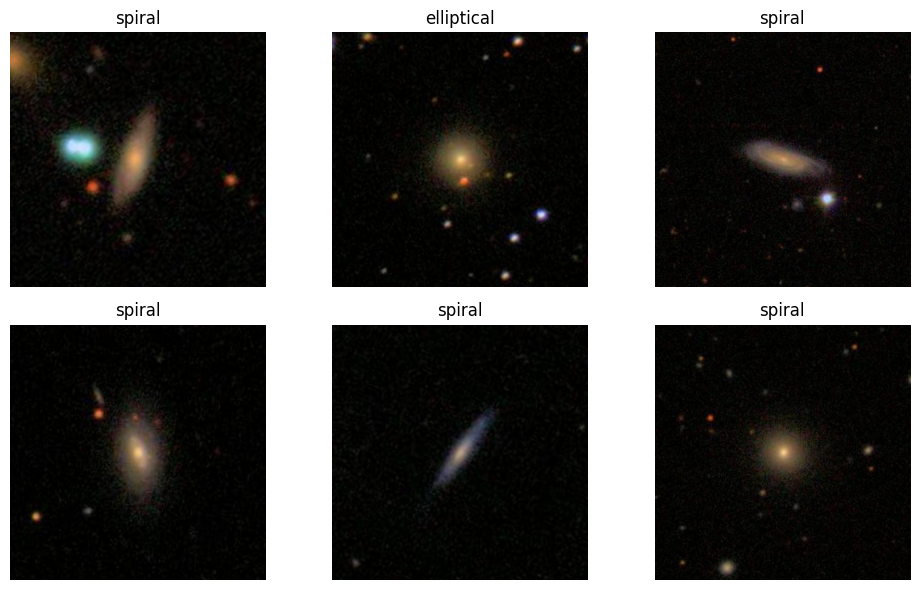

In [134]:
sample = filtered_df.sample(6)

plt.figure(figsize=(10, 6))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [135]:
model_df = filtered_df[["image_path", "label"]].copy()

print(model_df.shape)
print(model_df.head())
print(model_df["label"].value_counts())
print(model_df["image_path"].isna().sum())

(209278, 2)
                        image_path       label
0  ../data/images_gz2/images\3.jpg      spiral
1  ../data/images_gz2/images\4.jpg      spiral
2  ../data/images_gz2/images\5.jpg  elliptical
3  ../data/images_gz2/images\6.jpg      spiral
4  ../data/images_gz2/images\7.jpg      spiral
label
spiral        127848
elliptical     81430
Name: count, dtype: int64
0


## Dataset final para modelado

A partir del filtrado por confianza y la validación de rutas, se construye el dataset final que será utilizado en la etapa de modelado.

In [136]:
model_df["exists"] = model_df["image_path"].apply(os.path.exists)
print(model_df["exists"].value_counts())

model_df = model_df[model_df["exists"]].copy()
model_df.drop(columns="exists", inplace=True)

print("Shape final para modelado:", model_df.shape)
print(model_df["label"].value_counts())

exists
True     209225
False        53
Name: count, dtype: int64
Shape final para modelado: (209225, 2)
label
spiral        127812
elliptical     81413
Name: count, dtype: int64


# 3. División train / validation / test

In [137]:
train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (146457, 2)
Validation: (31384, 2)
Test: (31384, 2)


In [138]:
print("Distribución train")
print(train_df["label"].value_counts(normalize=True))

print("\nDistribución validation")
print(val_df["label"].value_counts(normalize=True))

print("\nDistribución test")
print(test_df["label"].value_counts(normalize=True))

Distribución train
label
spiral        0.610882
elliptical    0.389118
Name: proportion, dtype: float64

Distribución validation
label
spiral        0.610885
elliptical    0.389115
Name: proportion, dtype: float64

Distribución test
label
spiral        0.610885
elliptical    0.389115
Name: proportion, dtype: float64


## Justificación del split

Se utiliza una división estratificada para conservar la proporción de clases en train, validation y test.  
Esto permite una evaluación más confiable y reduce sesgos por desbalance.

In [139]:
label_map = {
    "elliptical": 0,
    "spiral": 1
}

train_df["label_id"] = train_df["label"].map(label_map)
val_df["label_id"] = val_df["label"].map(label_map)
test_df["label_id"] = test_df["label"].map(label_map)

print(train_df.head())

                                  image_path       label  label_id
177874  ../data/images_gz2/images\210317.jpg      spiral         1
75944    ../data/images_gz2/images\89801.jpg      spiral         1
71364    ../data/images_gz2/images\84765.jpg  elliptical         0
187349  ../data/images_gz2/images\220924.jpg  elliptical         0
51033    ../data/images_gz2/images\61587.jpg  elliptical         0


In [140]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# 4. Pipeline de datos en PyTorch

In [141]:
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label_id"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [167]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Entrenando", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        current_loss = running_loss / total
        current_acc = running_correct / total

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [143]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Validando", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            current_loss = running_loss / total
            current_acc = running_correct / total

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [163]:
def show_misclassified_samples(df, n=6):
    sample_df = df.sample(min(n, len(df)), random_state=42)

    plt.figure(figsize=(15, 8))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"Real: {class_names[row['y_true']]}\n"
            f"Pred: {class_names[row['y_pred']]}\n"
            f"Prob spiral: {row['y_prob']:.2f}"
        )

    plt.tight_layout()
    plt.show()

In [152]:
def get_predictions(model, dataloader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [155]:
class_names = {0: "elliptical", 1: "spiral"}

In [144]:
train_dataset = GalaxyDataset(train_df, transform=train_transform)
val_dataset = GalaxyDataset(val_df, transform=eval_transform)
test_dataset = GalaxyDataset(test_df, transform=eval_transform)

In [145]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [146]:
images, labels = next(iter(train_loader))

print("Shape de imágenes:", images.shape)
print("Shape de labels:", labels.shape)
print("Primeras labels:", labels[:10])

Shape de imágenes: torch.Size([32, 3, 128, 128])
Shape de labels: torch.Size([32])
Primeras labels: tensor([1., 1., 1., 1., 0., 1., 0., 1., 0., 1.])


## Nota sobre el pipeline

Se utiliza un `Dataset` personalizado y `DataLoader` para cargar imágenes y etiquetas desde rutas ya preparadas en el dataframe.  
Esto permite flexibilidad para comparar distintos modelos y transformaciones.

# 5. Modelo 1 — SimpleCNN baseline

El Modelo 1 corresponde a una CNN simple construida desde cero.  
Su propósito es establecer una línea base antes de introducir mejoras arquitectónicas o técnicas de data augmentation.

In [206]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [207]:
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [208]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [209]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Entrenando", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        current_loss = running_loss / total
        current_acc = running_correct / total

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [210]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Validando", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            current_loss = running_loss / total
            current_acc = running_correct / total

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [211]:
num_epochs = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())

In [212]:
test_file = os.path.join(IMAGE_DIR, "274197.jpg")
print(test_file)
print(os.path.exists(test_file))

../data/images_gz2/images\274197.jpg
False


In [213]:
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print("Mejor modelo guardado")


Epoch 1/5


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.4218 | Train Acc: 0.8057
Val Loss:   0.3540 | Val Acc:   0.8444
Mejor modelo guardado

Epoch 2/5


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

...

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.2967 | Train Acc: 0.8685
Val Loss:   0.2988 | Val Acc:   0.8655
Mejor modelo guardado

Epoch 5/5


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.2807 | Train Acc: 0.8770
Val Loss:   0.2989 | Val Acc:   0.8668


In [214]:
model.load_state_dict(best_model_wts)
print("Mejor val_loss cargado en el modelo.")

Mejor val_loss cargado en el modelo.


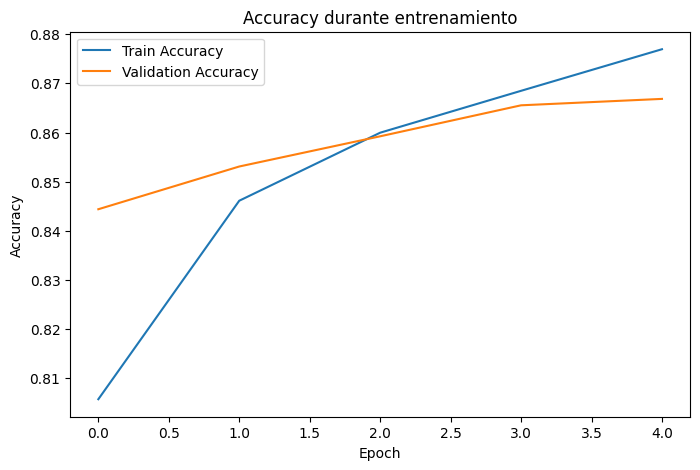

In [215]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante entrenamiento")
plt.legend()
plt.show()

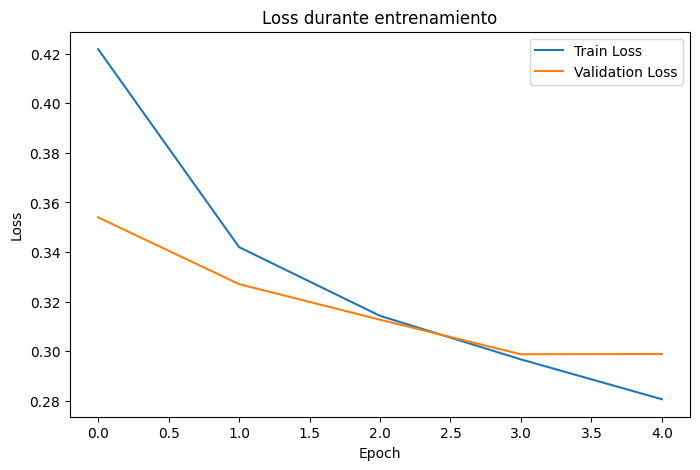

In [216]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante entrenamiento")
plt.legend()
plt.show()

<font size="4">Evaluacion</font>

In [217]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [218]:
def get_predictions(model, dataloader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [219]:
y_true, y_pred, y_prob = get_predictions(model, test_loader, device)

print("Test Accuracy:", accuracy_score(y_true, y_pred))

Test Accuracy: 0.8679581952587305


In [220]:
target_names = ["elliptical", "spiral"]

print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

  elliptical       0.83      0.84      0.83     12212
      spiral       0.90      0.89      0.89     19172

    accuracy                           0.87     31384
   macro avg       0.86      0.86      0.86     31384
weighted avg       0.87      0.87      0.87     31384



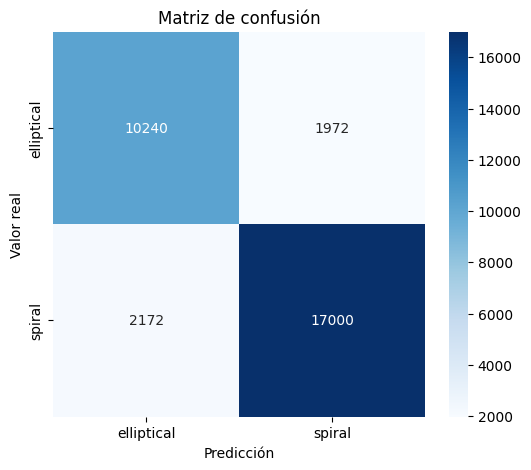

In [221]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.show()

In [222]:
test_results = test_df.reset_index(drop=True).copy()
test_results["y_true"] = y_true.astype(int)
test_results["y_pred"] = y_pred.astype(int)
test_results["y_prob"] = y_prob
test_results["correct"] = test_results["y_true"] == test_results["y_pred"]

test_results.head()

,image_path,label,label_id,y_true,y_pred,y_prob,correct
0,../data/images_gz2/images\19665.jpg,elliptical,0,0,0,0.037396,True
1,../data/images_gz2/images\79752.jpg,spiral,1,1,0,0.483487,False
2,../data/images_gz2/images\94681.jpg,spiral,1,1,1,0.869654,True
3,../data/images_gz2/images\33286.jpg,elliptical,0,0,0,0.279480,True
4,../data/images_gz2/images\4184.jpg,elliptical,0,0,0,0.016326,True


In [223]:
print(test_results["correct"].value_counts())

correct
True     27240
False     4144
Name: count, dtype: int64


In [224]:
class_names = {0: "elliptical", 1: "spiral"}

errors_df = test_results[test_results["correct"] == False].copy()
errors_df.head()

,image_path,label,label_id,y_true,y_pred,y_prob,correct
1,../data/images_gz2/images\79752.jpg,spiral,1,1,0,0.483487,False
5,../data/images_gz2/images\134620.jpg,spiral,1,1,0,0.399002,False
6,../data/images_gz2/images\4719.jpg,elliptical,0,0,1,0.670185,False
15,../data/images_gz2/images\176291.jpg,elliptical,0,0,1,0.576847,False
16,../data/images_gz2/images\111687.jpg,elliptical,0,0,1,0.576392,False


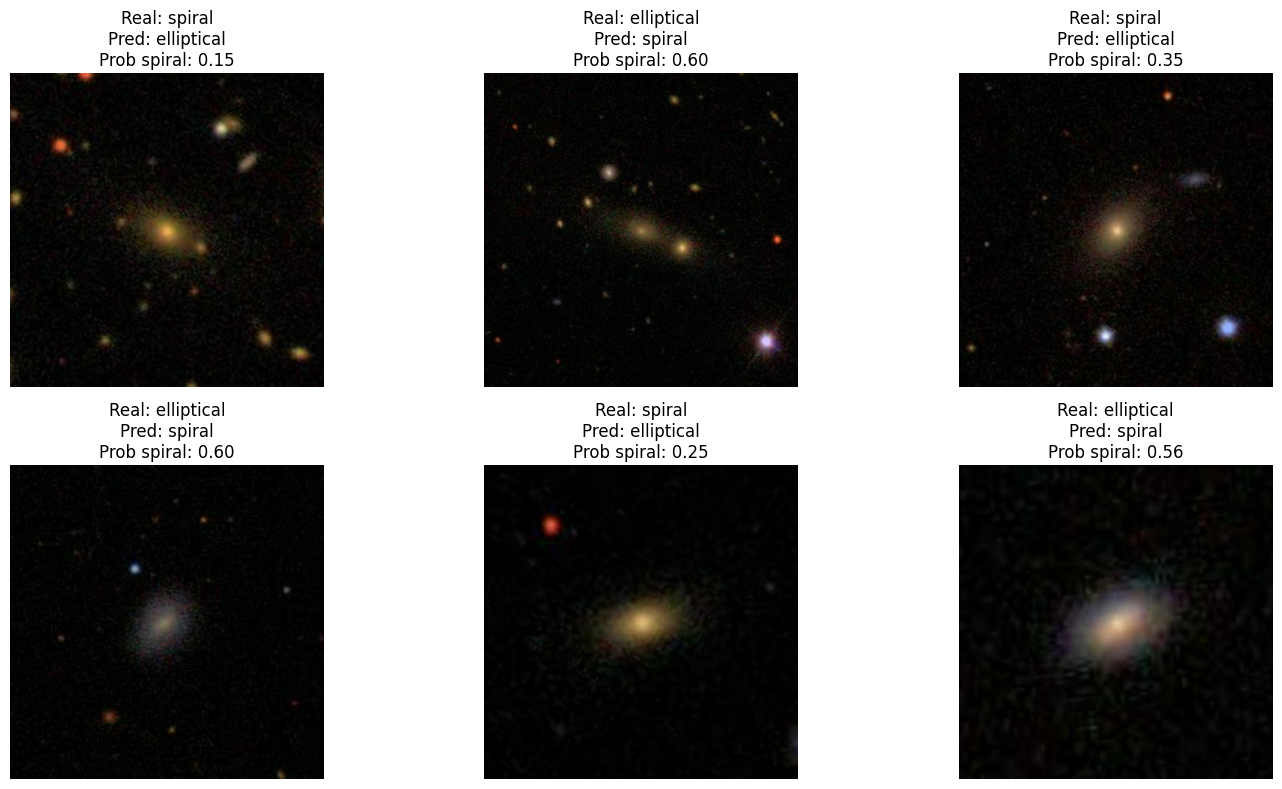

In [225]:
def show_misclassified_samples(df, n=6):
    sample_df = df.sample(min(n, len(df)), random_state=42)

    plt.figure(figsize=(15, 8))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"Real: {class_names[row['y_true']]}\n"
            f"Pred: {class_names[row['y_pred']]}\n"
            f"Prob spiral: {row['y_prob']:.2f}"
        )

    plt.tight_layout()
    plt.show()

show_misclassified_samples(errors_df, n=6)

## Conclusión del Modelo 1

La CNN base logra un desempeño sólido como línea base, aunque presenta confusiones entre clases visualmente ambiguas.  
Este resultado sirve como referencia para evaluar mejoras posteriores.

# 6. Modelo 2 — BetterCNN + Data Augmentation

En este segundo modelo se incorporan técnicas para mejorar robustez y estabilidad:
- data augmentation en entrenamiento
- Batch Normalization
- mayor regularización con dropout

In [ ]:
train_transform_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])

eval_transform_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [235]:
train_dataset_aug = GalaxyDataset(train_df, transform=train_transform_aug)
val_dataset_aug = GalaxyDataset(val_df, transform=eval_transform_aug)
test_dataset_aug = GalaxyDataset(test_df, transform=eval_transform_aug)

In [236]:
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)

In [237]:
images_aug, labels_aug = next(iter(train_loader_aug))

print("Shape de imágenes:", images_aug.shape)
print("Shape de labels:", labels_aug.shape)
print("Primeras labels:", labels_aug[:10])

Shape de imágenes: torch.Size([32, 3, 128, 128])
Shape de labels: torch.Size([32])
Primeras labels: tensor([1., 1., 0., 1., 0., 0., 1., 1., 0., 1.])


In [238]:
class BetterCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [239]:
model_2 = BetterCNN().to(device)
print(model_2)

BetterCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropo

In [240]:
criterion_2 = nn.BCEWithLogitsLoss()
optimizer_2 = optim.Adam(model_2.parameters(), lr=1e-3)

In [241]:
num_epochs_2 = 15

history_2 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss_2 = float("inf")
best_model_wts_2 = copy.deepcopy(model_2.state_dict())

In [242]:
for epoch in range(num_epochs_2):
    print(f"\nEpoch {epoch+1}/{num_epochs_2}")

    train_loss, train_acc = train_one_epoch(
        model_2, train_loader_aug, criterion_2, optimizer_2, device
    )
    val_loss, val_acc = evaluate(
        model_2, val_loader_aug, criterion_2, device
    )

    history_2["train_loss"].append(train_loss)
    history_2["train_acc"].append(train_acc)
    history_2["val_loss"].append(val_loss)
    history_2["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_loss < best_val_loss_2:
        best_val_loss_2 = val_loss
        best_model_wts_2 = copy.deepcopy(model_2.state_dict())
        print("Mejor modelo guardado")


Epoch 1/15


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.4579 | Train Acc: 0.7908
Val Loss:   0.3955 | Val Acc:   0.8233
Mejor modelo guardado

Epoch 2/15


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

...

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.2927 | Train Acc: 0.8722
Val Loss:   0.2873 | Val Acc:   0.8672

Epoch 15/15


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.2911 | Train Acc: 0.8721
Val Loss:   0.2729 | Val Acc:   0.8797
Mejor modelo guardado


In [243]:
model_2.load_state_dict(best_model_wts_2)
print("Mejor val_loss del Modelo 2 cargado.")
print("Best val_loss Modelo 2:", best_val_loss_2)

Mejor val_loss del Modelo 2 cargado.
Best val_loss Modelo 2: 0.27288889669958744


### Curvas de entrenamiento del Modelo 2

Se visualiza la evolución de accuracy y loss en entrenamiento y validación para analizar estabilidad, capacidad de aprendizaje y posibles señales de sobreajuste.

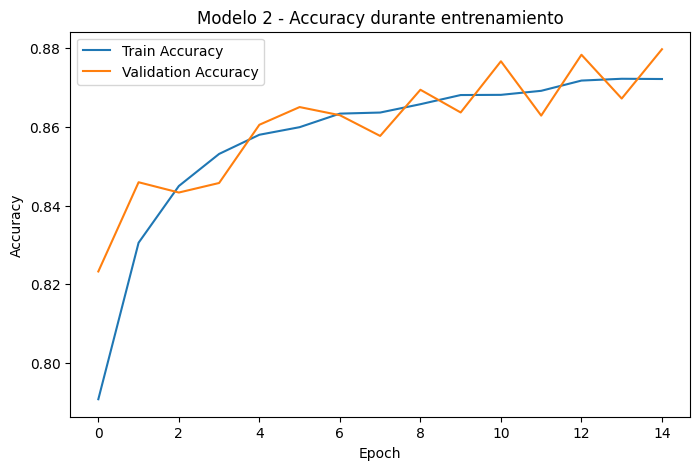

In [244]:
plt.figure(figsize=(8, 5))
plt.plot(history_2["train_acc"], label="Train Accuracy")
plt.plot(history_2["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Modelo 2 - Accuracy durante entrenamiento")
plt.legend()
plt.show()

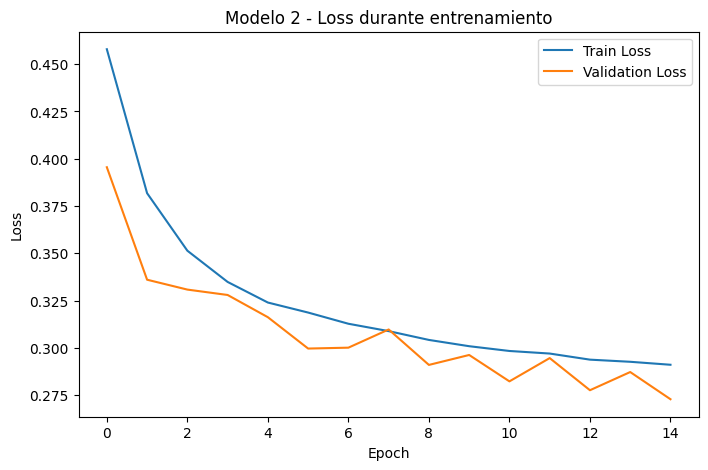

In [245]:
plt.figure(figsize=(8, 5))
plt.plot(history_2["train_loss"], label="Train Loss")
plt.plot(history_2["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Modelo 2 - Loss durante entrenamiento")
plt.legend()
plt.show()

### Evaluación en test del Modelo 2

Una vez cargado el mejor estado del modelo según validation loss, se evalúa su desempeño final sobre el conjunto de test.

In [246]:
y_true_2, y_pred_2, y_prob_2 = get_predictions(model_2, test_loader_aug, device)

test_acc_2 = accuracy_score(y_true_2, y_pred_2)

print("Test Accuracy Modelo 2:", test_acc_2)

Test Accuracy Modelo 2: 0.8814364007137395


In [248]:
target_names = ["elliptical", "spiral"]

report_2 = classification_report(
    y_true_2,
    y_pred_2,
    target_names=target_names,
    output_dict=True
)

print(classification_report(
    y_true_2,
    y_pred_2,
    target_names=target_names
))

              precision    recall  f1-score   support

  elliptical       0.84      0.86      0.85     12212
      spiral       0.91      0.89      0.90     19172

    accuracy                           0.88     31384
   macro avg       0.87      0.88      0.88     31384
weighted avg       0.88      0.88      0.88     31384



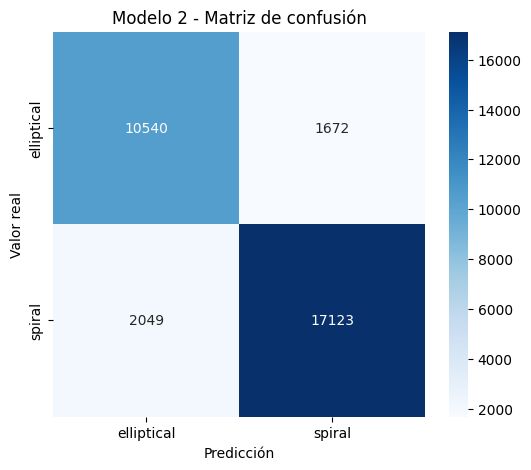

In [249]:
cm_2 = confusion_matrix(y_true_2, y_pred_2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Modelo 2 - Matriz de confusión")
plt.show()

### Análisis visual de errores del Modelo 2

Se inspeccionan ejemplos mal clasificados para identificar patrones ambiguos o limitaciones del modelo.

In [250]:
test_results_2 = test_df.reset_index(drop=True).copy()
test_results_2["y_true"] = y_true_2.astype(int)
test_results_2["y_pred"] = y_pred_2.astype(int)
test_results_2["y_prob"] = y_prob_2
test_results_2["correct"] = test_results_2["y_true"] == test_results_2["y_pred"]

test_results_2.head()

,image_path,label,label_id,y_true,y_pred,y_prob,correct
0,../data/images_gz2/images\19665.jpg,elliptical,0,0,0,0.054628,True
1,../data/images_gz2/images\79752.jpg,spiral,1,1,1,0.833198,True
2,../data/images_gz2/images\94681.jpg,spiral,1,1,1,0.886175,True
3,../data/images_gz2/images\33286.jpg,elliptical,0,0,0,0.178315,True
4,../data/images_gz2/images\4184.jpg,elliptical,0,0,0,0.033950,True


In [251]:
class_names = {0: "elliptical", 1: "spiral"}

errors_df_2 = test_results_2[test_results_2["correct"] == False].copy()

print(errors_df_2.shape)
errors_df_2.head()

(3721, 7)


,image_path,label,label_id,y_true,y_pred,y_prob,correct
6,../data/images_gz2/images\4719.jpg,elliptical,0,0,1,0.816640,False
15,../data/images_gz2/images\176291.jpg,elliptical,0,0,1,0.883791,False
16,../data/images_gz2/images\111687.jpg,elliptical,0,0,1,0.569329,False
18,../data/images_gz2/images\164941.jpg,spiral,1,1,0,0.485002,False
24,../data/images_gz2/images\243132.jpg,spiral,1,1,0,0.486587,False


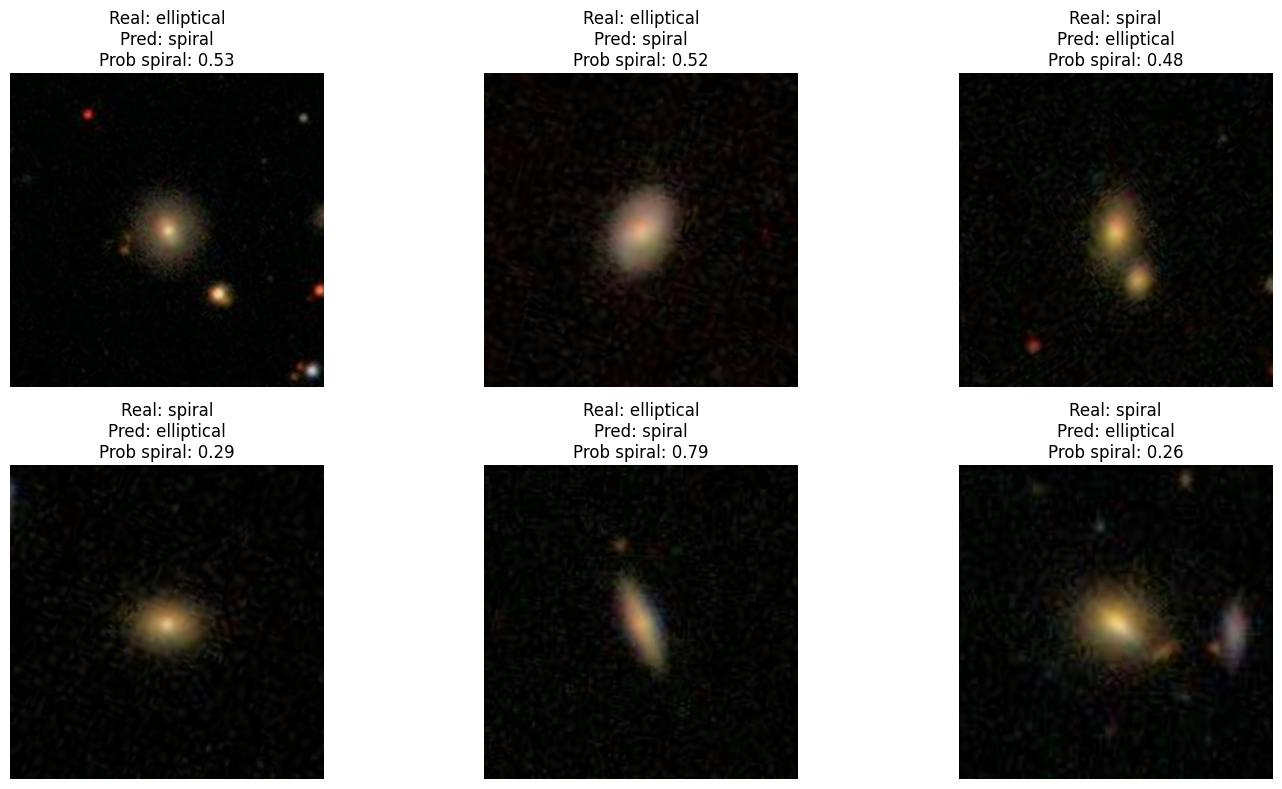

In [252]:
show_misclassified_samples(errors_df_2, n=6)

## Conclusión del Modelo 2

El Modelo 2 mejoró el desempeño del baseline al incorporar Batch Normalization y data augmentation. 
Las curvas de entrenamiento muestran un comportamiento estable, sin señales fuertes de sobreajuste, y el rendimiento en test aumentó respecto al Modelo 1.

El modelo alcanzó un test accuracy de 0.8814, con un mejor equilibrio entre clases y una reducción de errores sobre galaxias elípticas. 
Los errores restantes se concentran en ejemplos visualmente ambiguos, lo que sugiere que las mejoras introducidas ayudaron a la generalización del modelo.

# 7. Modelo 3 — Transfer Learning con ResNet18

En este modelo se utiliza transferencia de aprendizaje con ResNet18 preentrenada. 
El objetivo es comparar su desempeño frente a las CNN construidas desde cero, evaluando si el uso de conocimiento visual previo mejora la clasificación entre galaxias espirales y elípticas.

## Transformaciones para ResNet18

A diferencia de los modelos anteriores, ResNet18 requiere imágenes de tamaño 224x224 y normalización compatible con ImageNet.

In [95]:
IMG_SIZE_RESNET = 224

train_transform_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE_RESNET, IMG_SIZE_RESNET)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Datasets y DataLoaders del Modelo 3

In [96]:
train_dataset_resnet = GalaxyDataset(train_df, transform=train_transform_resnet)
val_dataset_resnet = GalaxyDataset(val_df, transform=eval_transform_resnet)
test_dataset_resnet = GalaxyDataset(test_df, transform=eval_transform_resnet)

In [97]:
train_loader_resnet = DataLoader(
    train_dataset_resnet,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_resnet = DataLoader(
    val_dataset_resnet,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_resnet = DataLoader(
    test_dataset_resnet,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

## Verificación del pipeline del Modelo 3

In [98]:
images_resnet, labels_resnet = next(iter(train_loader_resnet))

print("Shape de imágenes:", images_resnet.shape)
print("Shape de labels:", labels_resnet.shape)
print("Primeras labels:", labels_resnet[:10])

Shape de imágenes: torch.Size([8, 3, 224, 224])
Shape de labels: torch.Size([8])
Primeras labels: tensor([1., 1., 1., 1., 1., 0., 1., 0.])


## Arquitectura del Modelo 3

Se carga una ResNet18 preentrenada y se reemplaza la capa final para adaptarla a clasificación binaria.

In [99]:
from torchvision.models import resnet18, ResNet18_Weights
weights = ResNet18_Weights.DEFAULT
model_3 = resnet18(weights=weights)

In [100]:
num_features = model_3.fc.in_features
model_3.fc = nn.Linear(num_features, 1)

model_3 = model_3.to(device)
print(model_3)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Congelamiento inicial de capas

In [101]:
for param in model_3.parameters():
    param.requires_grad = False

for param in model_3.fc.parameters():
    param.requires_grad = True

## Configuración de entrenamiento del Modelo 3

In [102]:
criterion_3 = nn.BCEWithLogitsLoss()
optimizer_3 = optim.Adam(model_3.fc.parameters(), lr=1e-3)

num_epochs_3 = 10

history_3 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss_3 = float("inf")
best_model_wts_3 = copy.deepcopy(model_3.state_dict())

## Entrenamiento del Modelo 3

### Estrategia de entrenamiento del Modelo 3

En esta primera versión del modelo se congelan las capas convolucionales preentrenadas y se entrena únicamente la capa final de clasificación.  
Esto permite adaptar la red al problema binario sin modificar inicialmente los filtros visuales aprendidos.

In [103]:
trainable_params = sum(p.numel() for p in model_3.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_3.parameters())

print("Parámetros entrenables:", trainable_params)
print("Parámetros totales:", total_params)

Parámetros entrenables: 513
Parámetros totales: 11177025


In [104]:
for epoch in range(num_epochs_3):
    print(f"\nEpoch {epoch+1}/{num_epochs_3}")

    train_loss, train_acc = train_one_epoch(
        model_3, train_loader_resnet, criterion_3, optimizer_3, device
    )
    val_loss, val_acc = evaluate(
        model_3, val_loader_resnet, criterion_3, device
    )

    history_3["train_loss"].append(train_loss)
    history_3["train_acc"].append(train_acc)
    history_3["val_loss"].append(val_loss)
    history_3["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_loss < best_val_loss_3:
        best_val_loss_3 = val_loss
        best_model_wts_3 = copy.deepcopy(model_3.state_dict())
        print("Mejor modelo guardado")


Epoch 1/10


Entrenando:   0%|          | 0/18308 [00:00<?, ?it/s]

Validando:   0%|          | 0/3923 [00:00<?, ?it/s]

Train Loss: 0.5386 | Train Acc: 0.7289
Val Loss:   0.5090 | Val Acc:   0.7410
Mejor modelo guardado

Epoch 2/10


Entrenando:   0%|          | 0/18308 [00:00<?, ?it/s]

...

Validando:   0%|          | 0/3923 [00:00<?, ?it/s]

Train Loss: 0.5310 | Train Acc: 0.7348
Val Loss:   0.5017 | Val Acc:   0.7538
Mejor modelo guardado

Epoch 10/10


Entrenando:   0%|          | 0/18308 [00:00<?, ?it/s]

Validando:   0%|          | 0/3923 [00:00<?, ?it/s]

Train Loss: 0.5307 | Train Acc: 0.7340
Val Loss:   0.4990 | Val Acc:   0.7566
Mejor modelo guardado


In [147]:
model_3.load_state_dict(best_model_wts_3)
print("Mejor val_loss del Modelo 3 cargado.")
print("Best val_loss Modelo 3:", best_val_loss_3)

Mejor val_loss del Modelo 3 cargado.
Best val_loss Modelo 3: 0.4990267300241886


## Curvas de entrenamiento del Modelo 3

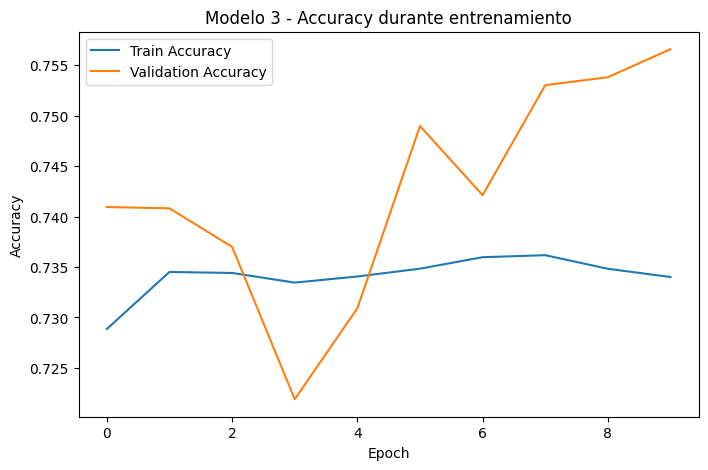

In [148]:
plt.figure(figsize=(8, 5))
plt.plot(history_3["train_acc"], label="Train Accuracy")
plt.plot(history_3["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Modelo 3 - Accuracy durante entrenamiento")
plt.legend()
plt.show()

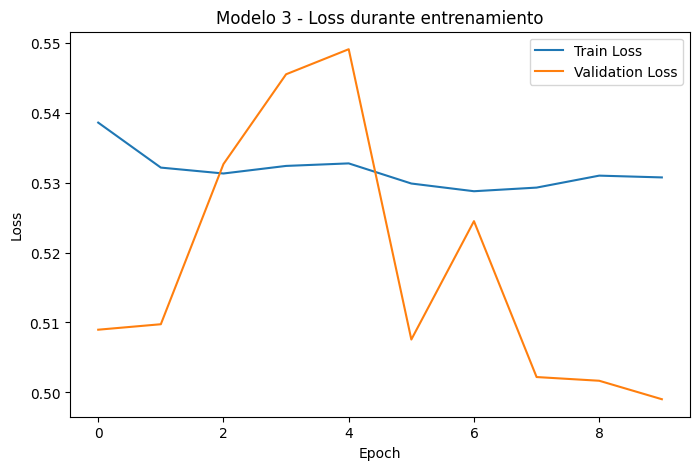

In [149]:
plt.figure(figsize=(8, 5))
plt.plot(history_3["train_loss"], label="Train Loss")
plt.plot(history_3["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Modelo 3 - Loss durante entrenamiento")
plt.legend()
plt.show()

## Evaluación en test del Modelo 3

In [156]:
y_true_3, y_pred_3, y_prob_3 = get_predictions(model_3, test_loader_resnet, device)

test_acc_3 = accuracy_score(y_true_3, y_pred_3)
print("Test Accuracy Modelo 3:", test_acc_3)

Test Accuracy Modelo 3: 0.7592403772622993


In [157]:
report_3 = classification_report(
    y_true_3,
    y_pred_3,
    target_names=["elliptical", "spiral"],
    output_dict=True
)

print(classification_report(
    y_true_3,
    y_pred_3,
    target_names=["elliptical", "spiral"]
))

              precision    recall  f1-score   support

  elliptical       0.70      0.66      0.68     12212
      spiral       0.79      0.82      0.81     19172

    accuracy                           0.76     31384
   macro avg       0.75      0.74      0.74     31384
weighted avg       0.76      0.76      0.76     31384



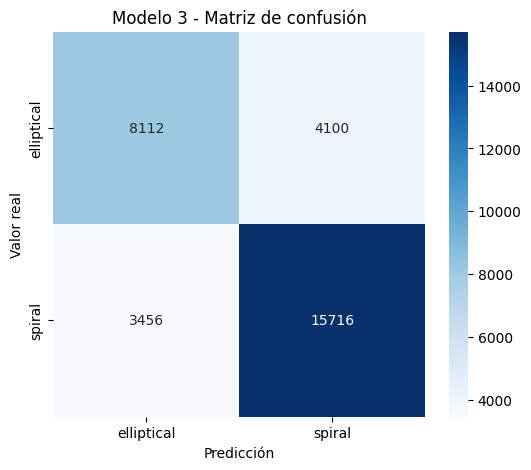

In [158]:
cm_3 = confusion_matrix(y_true_3, y_pred_3)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["elliptical", "spiral"],
    yticklabels=["elliptical", "spiral"]
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Modelo 3 - Matriz de confusión")
plt.show()

## Análisis visual de errores del Modelo 3

In [159]:
test_results_3 = test_df.reset_index(drop=True).copy()
test_results_3["y_true"] = y_true_3.astype(int)
test_results_3["y_pred"] = y_pred_3.astype(int)
test_results_3["y_prob"] = y_prob_3
test_results_3["correct"] = test_results_3["y_true"] == test_results_3["y_pred"]

errors_df_3 = test_results_3[test_results_3["correct"] == False].copy()

print(errors_df_3.shape)
errors_df_3.head()

(7556, 7)


,image_path,label,label_id,y_true,y_pred,y_prob,correct
0,../data/images_gz2/images\19665.jpg,elliptical,0,0,1,0.541866,False
1,../data/images_gz2/images\79752.jpg,spiral,1,1,0,0.483138,False
3,../data/images_gz2/images\33286.jpg,elliptical,0,0,1,0.684381,False
4,../data/images_gz2/images\4184.jpg,elliptical,0,0,1,0.557160,False
6,../data/images_gz2/images\4719.jpg,elliptical,0,0,1,0.766156,False


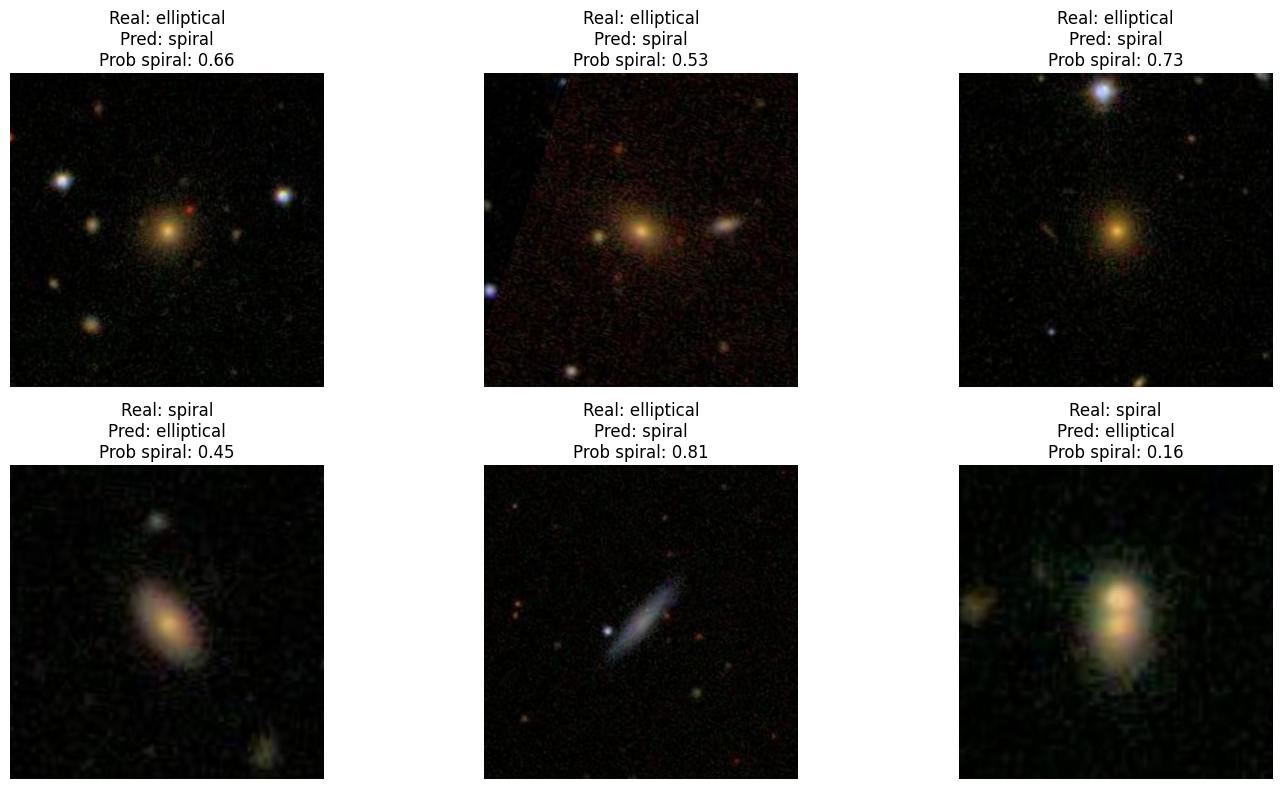

In [160]:
show_misclassified_samples(errors_df_3, n=6)

## Conclusión del Modelo 3

El modelo basado en transferencia de aprendizaje con ResNet18 no superó a las CNN entrenadas desde cero en este problema. 
Aunque se utilizó una red preentrenada, la estrategia de congelar todas las capas y entrenar únicamente la capa final resultó insuficiente para adaptarse al dominio astronómico.

El modelo alcanzó un test accuracy de 0.7592, claramente inferior al obtenido por el Modelo 2. 
Esto sugiere que, para este caso, los patrones aprendidos en ImageNet no se transfieren de manera óptima sin una etapa adicional de fine-tuning más profunda.

# 8. Comparación final de modelos

En esta sección se comparan los tres enfoques desarrollados:

- Modelo 1: SimpleCNN baseline
- Modelo 2: BetterCNN + Data Augmentation
- Modelo 3: Transfer Learning con ResNet18

La comparación se realizará usando métricas cuantitativas y análisis cualitativo de errores, con el fin de identificar el modelo más adecuado para el problema.

In [168]:
comparison_results = [
    {
        "model_name": "SimpleCNN baseline",
        "best_val_loss": 0.3118,
        "test_accuracy": 0.8628,
        "macro_f1": 0.85,
        "weighted_f1": 0.86,
        "elliptical_precision": 0.84,
        "elliptical_recall": 0.80,
        "elliptical_f1": 0.82,
        "spiral_precision": 0.88,
        "spiral_recall": 0.90,
        "spiral_f1": 0.89
    },
    {
        "model_name": "BetterCNN + augmentation",
        "best_val_loss": 0.2729,
        "test_accuracy": 0.8814,
        "macro_f1": 0.88,
        "weighted_f1": 0.88,
        "elliptical_precision": 0.84,
        "elliptical_recall": 0.86,
        "elliptical_f1": 0.85,
        "spiral_precision": 0.91,
        "spiral_recall": 0.89,
        "spiral_f1": 0.90
    },
    {
        "model_name": "ResNet18 transfer learning",
        "best_val_loss": 0.4990,
        "test_accuracy": 0.7592,
        "macro_f1": 0.74,
        "weighted_f1": 0.76,
        "elliptical_precision": 0.70,
        "elliptical_recall": 0.66,
        "elliptical_f1": 0.68,
        "spiral_precision": 0.79,
        "spiral_recall": 0.82,
        "spiral_f1": 0.81
    }
]

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True)
comparison_df

,model_name,best_val_loss,test_accuracy,macro_f1,weighted_f1,elliptical_precision,elliptical_recall,elliptical_f1,spiral_precision,spiral_recall,spiral_f1
0,BetterCNN + augmentation,0.2729,0.8814,0.88,0.88,0.84,0.86,0.85,0.91,0.89,0.90
1,SimpleCNN baseline,0.3118,0.8628,0.85,0.86,0.84,0.80,0.82,0.88,0.90,0.89
2,ResNet18 transfer learning,0.4990,0.7592,0.74,0.76,0.70,0.66,0.68,0.79,0.82,0.81


In [169]:
comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True)

comparison_df_rounded = comparison_df.copy()

metric_cols = [
    "best_val_loss", "test_accuracy", "macro_f1", "weighted_f1",
    "elliptical_precision", "elliptical_recall", "elliptical_f1",
    "spiral_precision", "spiral_recall", "spiral_f1"
]

comparison_df_rounded[metric_cols] = comparison_df_rounded[metric_cols].round(4)
comparison_df_rounded

,model_name,best_val_loss,test_accuracy,macro_f1,weighted_f1,elliptical_precision,elliptical_recall,elliptical_f1,spiral_precision,spiral_recall,spiral_f1
0,BetterCNN + augmentation,0.2729,0.8814,0.88,0.88,0.84,0.86,0.85,0.91,0.89,0.90
1,SimpleCNN baseline,0.3118,0.8628,0.85,0.86,0.84,0.80,0.82,0.88,0.90,0.89
2,ResNet18 transfer learning,0.4990,0.7592,0.74,0.76,0.70,0.66,0.68,0.79,0.82,0.81


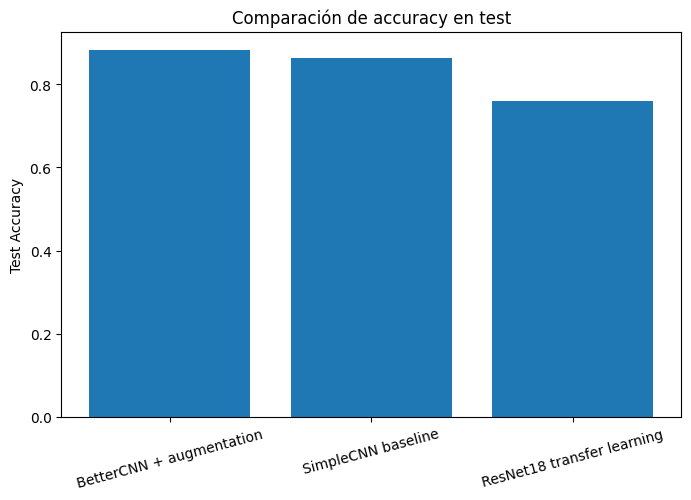

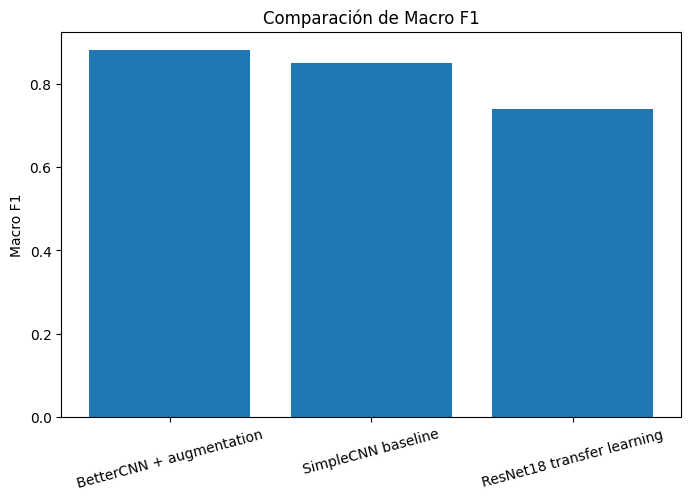

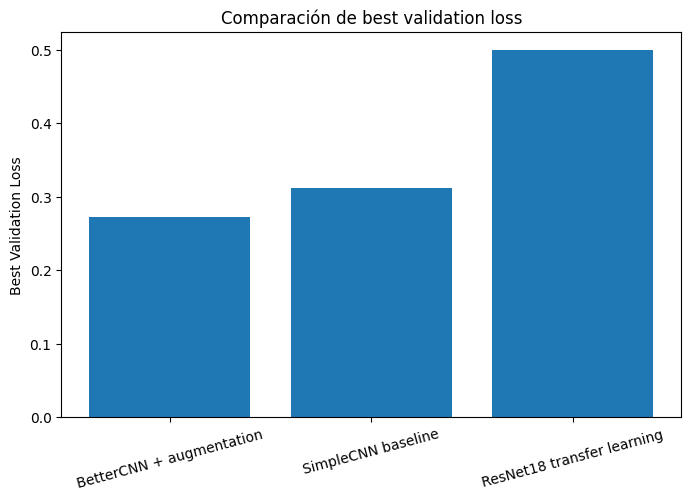

In [175]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df_rounded["model_name"], comparison_df_rounded["test_accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Comparación de accuracy en test")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df_rounded["model_name"], comparison_df_rounded["macro_f1"])
plt.ylabel("Macro F1")
plt.title("Comparación de Macro F1")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df_rounded["model_name"], comparison_df_rounded["best_val_loss"])
plt.ylabel("Best Validation Loss")
plt.title("Comparación de best validation loss")
plt.xticks(rotation=15)
plt.show()

In [176]:
class_comparison_df = comparison_df_rounded[
    [
        "model_name",
        "elliptical_precision", "elliptical_recall", "elliptical_f1",
        "spiral_precision", "spiral_recall", "spiral_f1"
    ]
]

class_comparison_df

,model_name,elliptical_precision,elliptical_recall,elliptical_f1,spiral_precision,spiral_recall,spiral_f1
0,BetterCNN + augmentation,0.84,0.86,0.85,0.91,0.89,0.90
1,SimpleCNN baseline,0.84,0.80,0.82,0.88,0.90,0.89
2,ResNet18 transfer learning,0.70,0.66,0.68,0.79,0.82,0.81


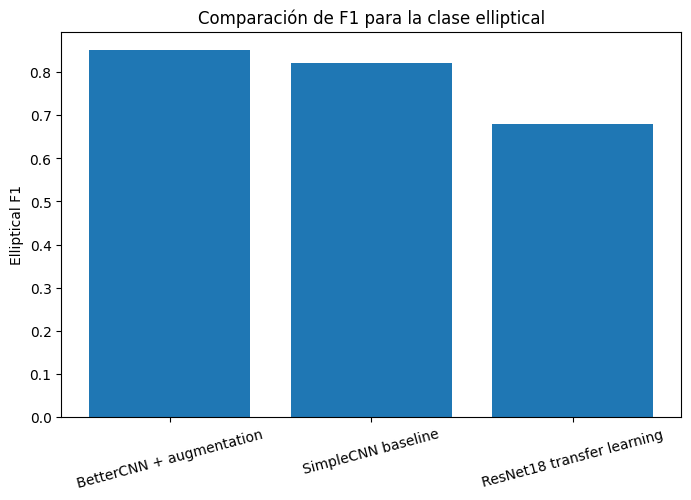

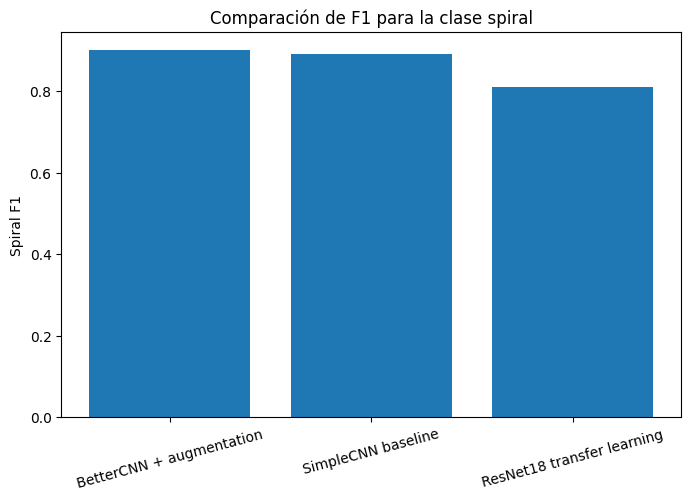

In [177]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df_rounded["model_name"], comparison_df_rounded["elliptical_f1"])
plt.ylabel("Elliptical F1")
plt.title("Comparación de F1 para la clase elliptical")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df_rounded["model_name"], comparison_df_rounded["spiral_f1"])
plt.ylabel("Spiral F1")
plt.title("Comparación de F1 para la clase spiral")
plt.xticks(rotation=15)
plt.show()

# 9. Conclusiones

El mejor modelo del proyecto fue **BetterCNN + Data Augmentation**, con el mejor desempeño en test y el mejor equilibrio entre ambas clases.

La CNN base funcionó como una línea de referencia sólida, pero fue superada por la versión mejorada, lo que muestra que Batch Normalization, Dropout y data augmentation sí aportaron valor real.

El modelo de transferencia con ResNet18 no logró superar a las CNN entrenadas desde cero en esta configuración. Esto sugiere que congelar la red y entrenar solo la capa final no fue suficiente para adaptarse al dominio astronómico.

En conjunto, el proyecto muestra que una arquitectura ajustada específicamente al problema puede rendir mejor que una estrategia de transferencia poco adaptada al dominio.